In [1]:
!pip install scikit-learn

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 52.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ------ --------------------------------- 7.3/42.2 MB 37.6 MB/s eta 0:00:01
   ------------ --------------------------- 13.1/42.2 MB 30.4 MB/s eta 0:00:01
   ----------------- ---------------------- 18.6/42.2 MB 29.4 MB/s eta 0:00:01
   ----------------------- ---------------- 24.4/42.2 MB 29.1 MB/s eta 0:00:01
   ---------------------------- ----------- 30.1/42.2 MB 28.5 MB/s eta 0:00:01
   ---------------------------------- ----- 36.2/42.2 MB 28.7 MB/s eta 0:00:01
   ---------------------------------------  42.2/42.2 MB 28.9 MB/s eta 0:00:01
   ---------------------------------------- 42.2/42.2 MB 27.1 MB/s eta 0:00:00


In [5]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   -- ------------------------------------- 8.1/124.9 MB 50.4 MB/s eta 0:00:03
   ----- ---------------------------------- 17.8/124.9 MB 48.9 MB/s eta 0:00:03
   -------- ------------------------------- 26.7/124.9 MB 47.0 MB/s eta 0:00:03
   ----------- ---------------------------- 35.9/124.9 MB 45.6 MB/s eta 0:00:02
   -------------- ------------------------- 45.1/124.9 MB 46.3 MB/s eta 0:00:02
   ----------------- ---------------------- 54.8/124.9 MB 45.9 MB/s eta 0:00:02
   -------------------- ------------------- 64.5/124.9 MB 46.2 MB/s eta 0:00:02
   ----------------------- ---------------- 74.2/124.9 MB 46.4 MB/s eta 0:00:02
   -------------------------- ------------- 83.9/124.9 MB 46.5 MB/s eta 0:00:01
   ------------------------------ --------- 93.8/124.9 MB 46.4 MB/s eta 0:00:01
   ------------------------------- ------- 102.2/124.9 MB 46.0 MB/s eta 0:00:01
   ---------------------------------- ---- 111.1/1

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [7]:
df = pd.read_csv("E:/Machine Learning/End to end project/mlprojects/notebook/data/stud.csv")

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X = df.drop(columns=['math_score'],axis=1)

In [10]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [11]:
y = df['math_score']

In [12]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [13]:
print("Categories in gender :",df['gender'].unique())
print("Categories in race_ethnicity :",df['race_ethnicity'].unique())
print("Categories in parental_level_of_education :",df['parental_level_of_education'].unique())
print("Categories in lunch :",df['lunch'].unique())
print("Categories in test_preparation_course :",df['test_preparation_course'].unique())



Categories in gender : ['female' 'male']
Categories in race_ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch : ['standard' 'free/reduced']
Categories in test_preparation_course : ['none' 'completed']


In [14]:
# Cretae column transformer with 3 types of transformer
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


numric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScalar',numric_transformer,num_features)
    ]
)

In [15]:
X = preprocessor.fit_transform(X)

In [17]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

# create an Evaluvation Function to give all matrics after model Training

In [21]:
def evaluvate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-neares Neighbour": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost":CatBoostRegressor(),
    "Adaboost":AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluvate Train and Test dataset

    model_train_mae,model_train_rmse,model_train_r2 = evaluvate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2 = evaluvate_model(y_test,y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Mode Performance for Training Set")
    print("Root Mean Squared Error = ",model_train_rmse)
    print("Mean Absolute Error",model_train_mae)
    print("R2 Score = ",model_train_r2)

    print("-----------------------------------------------------")

    print("Model Performance for Test Set")
    print("Root Mean Squared Error = ",model_test_rmse)
    print("Mean Absolute Error = ",model_test_mae)
    print("R2 Score = ",model_test_r2)

    r2_list.append(model_test_r2)

Linear Regression
Mode Performance for Training Set
Root Mean Squared Error =  5.32433097827426
Mean Absolute Error 4.26708984375
R2 Score =  0.8742567465397689
-----------------------------------------------------
Model Performance for Test Set
Root Mean Squared Error =  5.3959872842671395
Mean Absolute Error =  4.2158203125
R2 Score =  0.8803449074540941
Lasso
Mode Performance for Training Set
Root Mean Squared Error =  6.593815587795566
Mean Absolute Error 5.206302661246526
R2 Score =  0.8071462015863456
-----------------------------------------------------
Model Performance for Test Set
Root Mean Squared Error =  6.519694535667419
Mean Absolute Error =  5.157881810347763
R2 Score =  0.8253197323627853
Ridge
Mode Performance for Training Set
Root Mean Squared Error =  5.323324922741654
Mean Absolute Error 4.264987823725981
R2 Score =  0.8743042615212909
-----------------------------------------------------
Model Performance for Test Set
Root Mean Squared Error =  5.39038701693564
Me

e:\Machine Learning\End to end project\mlprojects\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\Machine Learning\End to end project\mlprojects\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "e:\Machine Learning\End to end project\mlprojects\venv\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "e:\Machine Learning\End to end project\mlprojects\venv\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\Machine Learning\End to end project\mlprojects\venv\lib\subp

Random Forest
Mode Performance for Training Set
Root Mean Squared Error =  2.299990972015796
Mean Absolute Error 1.833821875
R2 Score =  0.9765357398005287
-----------------------------------------------------
Model Performance for Test Set
Root Mean Squared Error =  6.029819707780104
Mean Absolute Error =  4.636241666666667
R2 Score =  0.8505836904149393
XGBoost
Mode Performance for Training Set
Root Mean Squared Error =  1.0072816866027385
Mean Absolute Error 0.6874666035175323
R2 Score =  0.9954995444196413
-----------------------------------------------------
Model Performance for Test Set
Root Mean Squared Error =  6.4733073671713335
Mean Absolute Error =  5.057730598449707
R2 Score =  0.8277965653186071
Learning rate set to 0.039525
0:	learn: 14.5987177	total: 142ms	remaining: 2m 21s
1:	learn: 14.2251886	total: 143ms	remaining: 1m 11s
2:	learn: 13.8866124	total: 143ms	remaining: 47.6s
3:	learn: 13.5235688	total: 144ms	remaining: 35.9s
4:	learn: 13.1887021	total: 145ms	remaining: 

In [23]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880345
7,CatBoost,0.851632
5,Random Forest,0.850584
8,Adaboost,0.844407
6,XGBoost,0.827797
1,Lasso,0.825320
3,K-neares Neighbour,0.783813
4,Decision Tree,0.732163


# Linear Regression

In [24]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy of the model is",score)

Accuracy of the model is 88.03449074540941


# Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

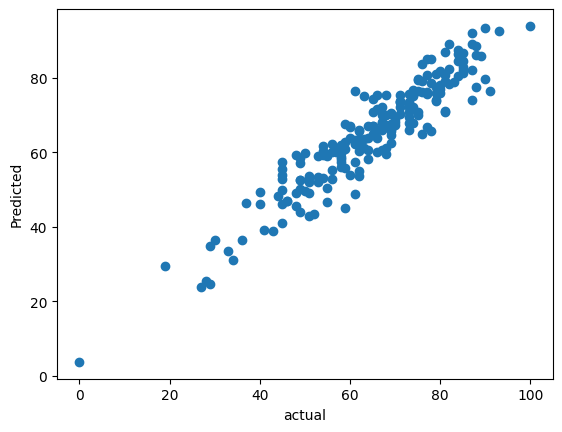

In [25]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

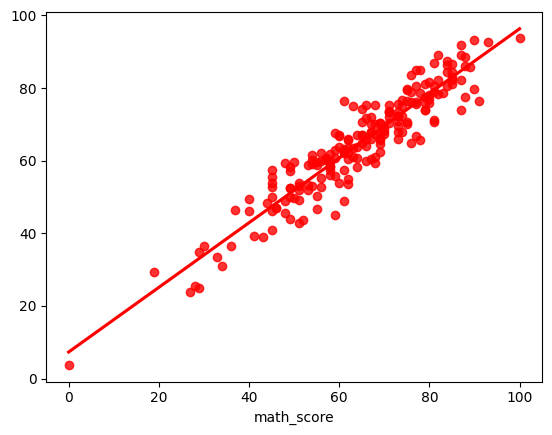

In [26]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [27]:
pred_df = pd.DataFrame({'Actual value':y_test, 'Predicted value': y_pred, 'Diffrence':y_test-y_pred})
pred_df

,Actual value,Predicted value,Diffrence
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
